In [153]:
# John Carlisle (jc97733)

# Option B, RLC Circut
# Equation basis: V(t) = q/C + Rdq/dt + Ld^2q/dt^2 where
# L = inductance (H)
# R = resistance (Ω)
# C = capacitance (F)
# q(t) = charge on capacitor (C)
# V(t) = external voltage (V)


In [154]:
# Parameter Research, initial values
# L = 10 mH
# R = 10 Ω
# C = 100 μF
# q(0) = 1*10^-3 C
# i(0) = 0 A
# based on values given from ChatGPT. 
# Cited source: "https://openstax.org/books/university-physics-volume-2/pages/14-6-rlc-series-circuits"
# ChatGPT link: "https://chatgpt.com/share/69e69561-4578-83ea-aaf0-b733a7df6e4e"


In [155]:
# Numerical implementation
# Equation math: d^2q/dt^2 = 1/L[V(t) - Rdq/dt - q/C]
# x1 = q(t)
# x2 = dq/dt
# New equation (after subsitutions)
# x2' = 1/L[V(t) - Rx2 - x1/C]
# New system:

# x1' = x2
# x2' = 1/L[V(t) - Rx2 - x1/C]



In [156]:
def f(t, y1, y2, R, L, C, V): # inital function declaration, like slide code
    return (1/L) * (V(t) - R*y2 - (1/C)*y1)

In [157]:
def euler_method(y1_0, y2_0, t0, tf, h, R, L, C, V):
    t = t0 # set values equal to initial values
    y1 = y1_0
    y2 = y2_0

    results = [] # initialize results list

    while t < tf: # add values
        results.append((t, y1, y2)) # stores results

        # derivatives
        dy1 = y2
        dy2 = f(t, y1, y2, R, L, C, V)

        # Euler updating
        y1_new = y1 + h * dy1
        y2_new = y2 + h * dy2

        y1, y2 = y1_new, y2_new
        t += h # add step size

    return results

In [158]:
def rk4_method(y1_0, y2_0, t0, tf, h, R, L, C, V):
    t = t0
    y1, y2 = y1_0, y2_0

    results = []

    while t < tf:
        results.append((t, y1, y2))

        # k1
        k1_y1 = y2
        k1_y2 = f(t, y1, y2, R, L, C, V)

        # k2
        y1_k2 = y1 + 0.5*h*k1_y1
        y2_k2 = y2 + 0.5*h*k1_y2
        k2_y1 = y2_k2
        k2_y2 = f(t + 0.5*h, y1_k2, y2_k2, R, L, C, V)

        # k3
        y1_k3 = y1 + 0.5*h*k2_y1
        y2_k3 = y2 + 0.5*h*k2_y2
        k3_y1 = y2_k3
        k3_y2 = f(t + 0.5*h, y1_k3, y2_k3, R, L, C, V)

        # k4
        y1_k4 = y1 + h*k3_y1
        y2_k4 = y2 + h*k3_y2
        k4_y1 = y2_k4
        k4_y2 = f(t + h, y1_k4, y2_k4, R, L, C, V)

        # update
        y1 += (h/6)*(k1_y1 + 2*k2_y1 + 2*k3_y1 + k4_y1)
        y2 += (h/6)*(k1_y2 + 2*k2_y2 + 2*k3_y2 + k4_y2)

        t += h

    return results

In [159]:
R = 10          # ohms
L = 10 * 10**-3         # henry
C = 100 * 10**-6      # farads

def V(t):
    return 1.0 if t >= 0 else 0.0  # step input voltage

y1_0 = 0   # no charge
y2_0 = 0   # no current

In [160]:
# Stability Analysis Below

Step Size Accuracy Comparison


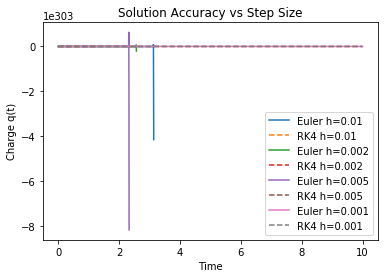

Stability Investigation
h = 0.001
  Euler: Stable
  RK4  : Stable
h = 0.002
  Euler: UNSTABLE
  RK4  : Stable
h = 0.003
  Euler: UNSTABLE
  RK4  : UNSTABLE
h = 0.004
  Euler: UNSTABLE
  RK4  : UNSTABLE
h = 0.005
  Euler: UNSTABLE
  RK4  : UNSTABLE
h = 0.01
  Euler: UNSTABLE
  RK4  : UNSTABLE
h = 0.02
  Euler: UNSTABLE
  RK4  : UNSTABLE
h = 0.05
  Euler: UNSTABLE
  RK4  : UNSTABLE
h = 0.1
  Euler: UNSTABLE
  RK4  : UNSTABLE
Unstable Behavior


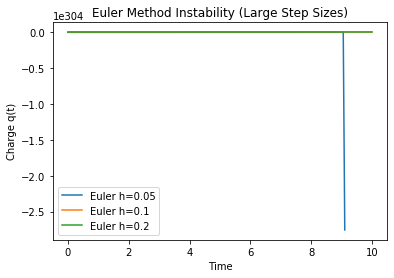

In [161]:
import matplotlib.pyplot as plt

# unpack results
def unpack(sol):
    t_vals = []
    y1_vals = []
    y2_vals = []
    for t, y1, y2 in sol:
        t_vals.append(t)
        y1_vals.append(y1)
        y2_vals.append(y2)
    return t_vals, y1_vals, y2_vals # reduce tuple to lists, better for graphs later.


# compare step size accuracy
print("Step Size Accuracy Comparison")

step_sizes = [0.01, 0.002, 0.005, 0.001]

plt.figure()

for h in step_sizes:
    euler_sol = euler_method(y1_0, y2_0, 0, 10, h, R, L, C, V)
    rk4_sol = rk4_method(y1_0, y2_0, 0, 10, h, R, L, C, V)

    t_e, y1_e, _ = unpack(euler_sol)
    t_r, y1_r, _ = unpack(rk4_sol)

    plt.plot(t_e, y1_e, label=f"Euler h={h}")
    plt.plot(t_r, y1_r, linestyle='dashed', label=f"RK4 h={h}")

plt.title("Solution Accuracy vs Step Size")
plt.xlabel("Time")
plt.ylabel("Charge q(t)")
plt.legend()
plt.show()


# check stability function
def is_unstable(y_vals):
    for val in y_vals:
        if abs(val) > 10:   # error gets too big
            return True
    return False


# get max step size
print("Stability Investigation")

test_steps = [0.001, 0.002, 0.003, 0.004, 0.005, 0.01, 0.02, 0.05, 0.1] # check all the sizes

for h in test_steps:
    euler_sol = euler_method(y1_0, y2_0, 0, 10, h, R, L, C, V)
    rk4_sol = rk4_method(y1_0, y2_0, 0, 10, h, R, L, C, V)

    _, y1_e, _ = unpack(euler_sol)
    _, y1_r, _ = unpack(rk4_sol)

    euler_unstable = is_unstable(y1_e)
    rk4_unstable = is_unstable(y1_r)

    print(f"h = {h}")
    print("  Euler:", "UNSTABLE" if euler_unstable else "Stable")
    print("  RK4  :", "UNSTABLE" if rk4_unstable else "Stable")


# plot generation
print("Unstable Behavior")

large_steps = [0.05, 0.1, 0.2]

plt.figure()

for h in large_steps:
    euler_sol = euler_method(y1_0, y2_0, 0, 10, h, R, L, C, V)
    t_e, y1_e, _ = unpack(euler_sol)

    plt.plot(t_e, y1_e, label=f"Euler h={h}")

plt.title("Euler Method Instability (Large Step Sizes)")
plt.xlabel("Time")
plt.ylabel("Charge q(t)")
plt.legend()
plt.show()

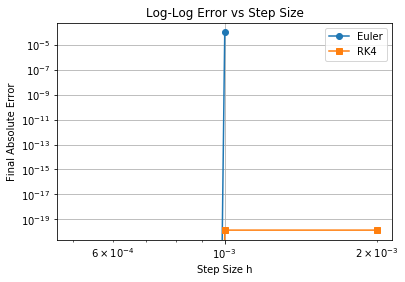

In [162]:
# Maximum stable step size is 0.001 for Euler, 0.002 for RK4


# # plot generation for error v step size
step_sizes = [0.008, 0.004, 0.002, 0.001, 0.0005]

euler_final_errors = []
rk4_final_errors = []

for h in step_sizes:
    euler_sol = euler_method(y1_0, y2_0, 0, 10, h, R, L, C, V)
    rk4_sol = rk4_method(y1_0, y2_0, 0, 10, h, R, L, C, V)

    t_e, q_e, _ = unpack(euler_sol)
    t_r, q_r, _ = unpack(rk4_sol)

    q_exact_end_e = exact_q(t_e[-1], R, L, C)
    q_exact_end_r = exact_q(t_r[-1], R, L, C)

    euler_final_errors.append(abs(q_e[-1] - q_exact_end_e))
    rk4_final_errors.append(abs(q_r[-1] - q_exact_end_r)) 

plt.figure()
plt.loglog(step_sizes, euler_final_errors, 'o-', label="Euler")
plt.loglog(step_sizes, rk4_final_errors, 's-', label="RK4")
plt.xlabel("Step Size h")
plt.ylabel("Final Absolute Error")
plt.title("Log-Log Error vs Step Size")
plt.legend()
plt.grid(True)
plt.show() # show graph